# 03. Pandas con datos del SNIES

**Curso:** Análisis de datos para la investigación con Python

**Propósito:** Leer, comprender, limpiar, filtrar, resumir e integrar dos archivos reales del Sistema Nacional de Información de la Educación Superior.

**Ruta:** archivos originales → revisión → limpieza → integración → respuesta

Este cuaderno está pensado para una clase virtual demostrativa. Primero se explica la idea, luego se observa el código y, después de varios ejemplos, aparece una pausa práctica.


## Cómo trabajar en Google Colab

1. Guarda una copia del notebook en tu Drive.
2. Ejecuta en orden con el botón de reproducción o con `Shift + Enter`.
3. Una celda de texto explica y una celda de código ejecuta instrucciones.
4. Si reinicias el entorno, usa **Entorno de ejecución → Ejecutar todas**.
5. En las pausas prácticas modifica la celda marcada y luego compara con la solución.

Un error no daña el computador. Lee la última línea del mensaje y revisa nombres, mayúsculas, comillas, paréntesis e indentación.


## Pregunta orientadora

**¿Cómo se distribuyen los programas activos del área de economía, administración, contaduría y afines según sector, modalidad, nivel y territorio?**

La unidad de análisis es el **programa académico ofrecido**. Antes de contar revisaremos qué representa cada fila, cuáles registros son válidos y qué información falta.


## 1. Subir y leer los archivos

En el sitio del SNIES el docente mostrará cómo descargar `Instituciones.xlsx` y `Programas.xlsx`. En Colab abre el icono de carpeta, pulsa **Subir al almacenamiento de la sesión**, selecciona ambos archivos y verifica sus nombres.

No usaremos una función para buscarlos. Las rutas quedan visibles y pueden reemplazarse por las que Colab permita copiar.


In [ ]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Los archivos del SNIES no incluyen un estilo predeterminado de Excel.
# OpenPyXL puede aplicar uno sin afectar los datos; ocultamos solo ese aviso conocido.
warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style"
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
print("Pandas:", pd.__version__)


Pandas: 2.2.3


In [ ]:
ruta_instituciones = "Instituciones.xlsx"
ruta_programas = "Programas.xlsx"

instituciones_original = pd.read_excel(
    ruta_instituciones, sheet_name="Instituciones"
)
programas_original = pd.read_excel(
    ruta_programas, sheet_name="Programas"
)
print("Archivos leídos correctamente")


Archivos leídos correctamente


Como son archivos de Excel usamos `pd.read_excel()`. Para un CSV la instrucción equivalente es `datos = pd.read_csv("archivo.csv")`. Si el separador es punto y coma se agrega `sep=";"`.


## 2. DataFrame, Series y primera observación

Un `DataFrame` es una tabla con filas, columnas e índice. Una columna individual suele ser una `Series`. Primero observamos; todavía no limpiamos.


In [ ]:
print(type(programas_original))
print(type(programas_original.iloc[:, 0]))


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [ ]:
programas_original.head()

,CÓDIGO_INSTITUCIÓN_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO_INSTITUCIÓN,CARÁCTER_ACADÉMICO,SECTOR,REGISTRO_UNICO,CÓDIGO_SNIES_DEL_PROGRAMA,CÓDIGO_ANTERIOR_ICFES,NOMBRE_DEL_PROGRAMA,TITULO_OTORGADO,ESTADO_PROGRAMA,JUSTIFICACION,JUSTIFICACION_DETALLADA,RECONOCIMIENTO_DEL_MINISTERIO,RESOLUCIÓN_DE_APROBACIÓN,FECHA_DE_RESOLUCIÓN,FECHA_EJECUTORIA,VIGENCIA_AÑOS,FECHA_DE_REGISTRO_EN_SNIES,CINE_F_2013_AC_CAMPO_AMPLIO,CINE_F_2013_AC_CAMPO_ESPECÍFIC,CINE_F_2013_AC_CAMPO_DETALLADO,ÁREA_DE_CONOCIMIENTO,NÚCLEO_BÁSICO_DEL_CONOCIMIENTO,NIVEL_ACADÉMICO,NIVEL_DE_FORMACIÓN,MODALIDAD,NÚMERO_CRÉDITOS,NÚMERO_PERIODOS_DE_DURACIÓN,PERIODICIDAD,SE_OFRECE_POR_CICLOS_PROPEDÉUT,PERIODICIDAD_ADMISIONES,PROGRAMA_EN_CONVENIO,DEPARTAMENTO_OFERTA_PROGRAMA,MUNICIPIO_OFERTA_PROGRAMA,COSTO_MATRÍCULA_ESTUD_NUEVOS,VIGENCIA TRANSITORIA,OBSERVACIÓN DECRETO 1174/23
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,19.0,110146580001100111100,ADMINISTRACION DE EMPRESAS,ADMINISTRADOR(A) DE EMPRESAS,Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,6,1998-03-21 08:21:46,Administración de Empresas y Derecho,Educación comercial y administración,Gestión y administración,"Economía, administración, contaduría y afines",Administración,Pregrado,Universitario,Presencial,164.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
1,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,13.0,110143010101100111100,ANTROPOLOGIA,"ANTROPÓLOGO, ANTROPÓLOGA O PROFESIONAL EN ANTROPOLOGÍA",Activo,NaN,NaN,Registro calificado,NaN,NaT,NaT,15,1998-03-21 08:21:36,Arte y Humanidades,Humanidades (Excepto idiomas),Historia y arqueología,Ciencias sociales y humanas,Antropología y artes liberales,Pregrado,Universitario,Presencial,122.0,9.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
2,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,30.0,110147200001100111100,ARQUITECTURA,ARQUITECTO(A),Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,6,1998-03-21 08:22:13,"Ingeniería, Industria y Construcción",Arquitectura y construcción,Arquitectura y urbanismo,"Ingeniería, arquitectura, urbanismo y afines",Arquitectura y afines,Pregrado,Universitario,Presencial,179.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
3,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,2497.0,110147300001100111100,ARTES PLASTICAS,"MAESTRO EN ARTES PLÁSTICAS, MAESTRA EN ARTES PLÁSTICAS O PROFESIONAL EN ARTE...",Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,8,1998-03-21 08:22:01,Arte y Humanidades,Artes,Bellas artes,Bellas artes,"Artes plásticas, visuales y afines",Pregrado,Universitario,Presencial,166.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
4,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,31.0,110145740001100111100,BIOLOGIA,"BIÓLOGO, BIÓLOGA O PROFESIONAL EN BIOLOGÍA",Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,8,1998-03-21 08:22:15,"Ciencias Naturales, Matemáticas y Estadística",Ciencias biológicas y afines,Biología,Matemáticas y ciencias naturales,"Biología, microbiología y afines",Pregrado,Universitario,Presencial,163.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN


In [ ]:
instituciones_original.head()


,CÓDIGO_IES_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO,NÚM_IDENTIFIC_TRIBUTARIA_NIT,PRINCIPAL_SECCIONAL,NATURALEZA_JURÍDICA,SECTOR,CARÁCTER_ACADÉMICO,DEPARTAMENTO_DOMICILIO,MUNICIPIO_DOMICILIO,DIRECCIÓN_DOMICILIO,TELÉFONO_DOMICILIO,ENTE_EMITE_NORMA_CREACIÓN,ACTO_ADMIN_NORMA_DE_CREACIÓN,NÚMERO_NORMA_DE_CREACIÓN,FECHA_NORMA_DE_CREACIÓN,PROGRAMAS_VIGENTES,PROGRAMAS_EN_CONVENIO,PÁGINA_WEB,ACREDITADA_ALTA_CALIDAD,FECHA_ACREDITACIÓN,RESOLUCIÓN_DE_LA_ACREDITACIÓN,VIGENCIA_DE_LA_ACREDITACIÓN,MISIÓN
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",Carrera 45 #26 - 85,3165000,Ley,Congreso de la Rep¿blica,66,1899-12-29,275.0,4.0,www.unal.edu.co,S,2021-08-25,15859.0,10.0,MISION
1,1101,1102,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Antioquia,Medellín,"Calle 59A No 63 - 20, N¿cleo El Volador",4309000,Ley,Congreso de la Republica,66,1899-12-29,124.0,NaN,www.medellin.unal.edu.co,S,2021-08-25,15859.0,10.0,MISION
2,1101,1103,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Caldas,Manizales,Carrera 27 No. 64-60,8879300,Ley,Congreso de la Republica,66,1899-12-29,69.0,NaN,www.manizales.unal.edu.co,S,2021-08-25,15859.0,10.0,"SERVIR A LA SOCIEDAD MEDIANTE LA CONSTRUCCI¿N DE NACI¿N DESDE LA REGI¿N, Y L..."
3,1101,1104,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Valle del Cauca,Palmira,"Carrera 32 No 12 - 00 Chapinero, V¿a Candelaria",2868888,Ley,Congreso de la Republica,66,1899-12-29,22.0,NaN,www.palmira.unal.edu.co,S,2021-08-25,15859.0,10.0,"SE DEFINE COMO UN ENTE AUTONOMO, QUE CONFORME A LA CONSTITUCION NACIONAL DEB..."
4,1105,1105,UNIVERSIDAD PEDAGOGICA NACIONAL,Activa,899.999.124-4,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",Calle 73 No.11-95,3471190,Decreto,Gobierno Nacional,197,1955-02-01,41.0,NaN,www.pedagogica.edu.co,S,2021-08-12,14621.0,6.0,LA UNIVERSIDAD PEDAGOGICA NACIONAL IMPULSA CONFORME A SUS ORIGENES Y VISION ...


`head()` muestra el inicio, `tail()` el final y `sample()` una muestra aleatoria. Ninguno reemplaza una revisión sistemática, pero juntos revelan encabezados, ejemplos y notas finales.


In [ ]:
programas_original.tail()


,CÓDIGO_INSTITUCIÓN_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO_INSTITUCIÓN,CARÁCTER_ACADÉMICO,SECTOR,REGISTRO_UNICO,CÓDIGO_SNIES_DEL_PROGRAMA,CÓDIGO_ANTERIOR_ICFES,NOMBRE_DEL_PROGRAMA,TITULO_OTORGADO,ESTADO_PROGRAMA,JUSTIFICACION,JUSTIFICACION_DETALLADA,RECONOCIMIENTO_DEL_MINISTERIO,RESOLUCIÓN_DE_APROBACIÓN,FECHA_DE_RESOLUCIÓN,FECHA_EJECUTORIA,VIGENCIA_AÑOS,FECHA_DE_REGISTRO_EN_SNIES,CINE_F_2013_AC_CAMPO_AMPLIO,CINE_F_2013_AC_CAMPO_ESPECÍFIC,CINE_F_2013_AC_CAMPO_DETALLADO,ÁREA_DE_CONOCIMIENTO,NÚCLEO_BÁSICO_DEL_CONOCIMIENTO,NIVEL_ACADÉMICO,NIVEL_DE_FORMACIÓN,MODALIDAD,NÚMERO_CRÉDITOS,NÚMERO_PERIODOS_DE_DURACIÓN,PERIODICIDAD,SE_OFRECE_POR_CICLOS_PROPEDÉUT,PERIODICIDAD_ADMISIONES,PROGRAMA_EN_CONVENIO,DEPARTAMENTO_OFERTA_PROGRAMA,MUNICIPIO_OFERTA_PROGRAMA,COSTO_MATRÍCULA_ESTUD_NUEVOS,VIGENCIA TRANSITORIA,OBSERVACIÓN DECRETO 1174/23
32037,9947,9947,"FUNDACIÓN UNIVERSITARIA PARA LA INVESTIGACIÓN, EL DESARROLLO TECNOLÓGICO Y L...",Activa,Institución Universitaria/Escuela Tecnológica,Privado,2011.0,118953.0,NaN,TECNOLOGIA EN DESARROLLO DE SOFTWARE,TECNOLOGO EN DESARROLLO SOFTWARE,Activo,NaN,NaN,Registro calificado,1829.0,2026-01-23,2026-01-29,7,2026-01-29,Tecnologías de la Información y la Comunicación (TIC),Tecnologías de la Información y la Comunicación (TIC),Desarrollo y análisis de software y aplicaciones,"Ingeniería, arquitectura, urbanismo y afines","Ingeniería de sistemas, telemática y afines",Pregrado,Tecnológico,Presencial,105.0,6.0,NaN,No,Semestral,N,Atlántico,Barranquilla,NaN,NaN,NaN
32038,9947,9947,"FUNDACIÓN UNIVERSITARIA PARA LA INVESTIGACIÓN, EL DESARROLLO TECNOLÓGICO Y L...",Activa,Institución Universitaria/Escuela Tecnológica,Privado,1940.0,118816.0,NaN,TECNOLOGIA EN GESTION EN DESARROLLO DE PROYECTOS,TECNOLOGO EN GESTION EN DESARROLLO DE PROYECTOS,Activo,NaN,NaN,Registro calificado,5253.0,2026-02-24,2026-02-26,7,2026-02-26,Administración de Empresas y Derecho,Programas y certificaciones interdisciplinarios relativos a administración d...,Programas y certificaciones interdisciplinarios relativos a administración d...,"Economía, administración, contaduría y afines",Administración,Pregrado,Tecnológico,Virtual,108.0,6.0,Semestral,No,Semestral,N,Atlántico,Barranquilla,NaN,NaN,NaN
32039,9947,9947,"FUNDACIÓN UNIVERSITARIA PARA LA INVESTIGACIÓN, EL DESARROLLO TECNOLÓGICO Y L...",Activa,Institución Universitaria/Escuela Tecnológica,Privado,1940.0,118815.0,NaN,TECNOLOGIA EN GESTION EN DESARROLLO DE PROYECTOS,TECNOLOGO EN GESTION EN DESARROLLO DE PROYECTOS,Activo,NaN,NaN,Registro calificado,5253.0,2026-02-24,2026-02-26,7,2026-02-26,Administración de Empresas y Derecho,Programas y certificaciones interdisciplinarios relativos a administración d...,Programas y certificaciones interdisciplinarios relativos a administración d...,"Economía, administración, contaduría y afines",Administración,Pregrado,Tecnológico,Presencial,108.0,6.0,Semestral,No,Semestral,N,Atlántico,Barranquilla,NaN,NaN,NaN
32040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32041,NOTA:,La información del presente reporte corresponde a los datos de caracterizaci...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
programas_original.sample(3, random_state=42)


,CÓDIGO_INSTITUCIÓN_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO_INSTITUCIÓN,CARÁCTER_ACADÉMICO,SECTOR,REGISTRO_UNICO,CÓDIGO_SNIES_DEL_PROGRAMA,CÓDIGO_ANTERIOR_ICFES,NOMBRE_DEL_PROGRAMA,TITULO_OTORGADO,ESTADO_PROGRAMA,JUSTIFICACION,JUSTIFICACION_DETALLADA,RECONOCIMIENTO_DEL_MINISTERIO,RESOLUCIÓN_DE_APROBACIÓN,FECHA_DE_RESOLUCIÓN,FECHA_EJECUTORIA,VIGENCIA_AÑOS,FECHA_DE_REGISTRO_EN_SNIES,CINE_F_2013_AC_CAMPO_AMPLIO,CINE_F_2013_AC_CAMPO_ESPECÍFIC,CINE_F_2013_AC_CAMPO_DETALLADO,ÁREA_DE_CONOCIMIENTO,NÚCLEO_BÁSICO_DEL_CONOCIMIENTO,NIVEL_ACADÉMICO,NIVEL_DE_FORMACIÓN,MODALIDAD,NÚMERO_CRÉDITOS,NÚMERO_PERIODOS_DE_DURACIÓN,PERIODICIDAD,SE_OFRECE_POR_CICLOS_PROPEDÉUT,PERIODICIDAD_ADMISIONES,PROGRAMA_EN_CONVENIO,DEPARTAMENTO_OFERTA_PROGRAMA,MUNICIPIO_OFERTA_PROGRAMA,COSTO_MATRÍCULA_ESTUD_NUEVOS,VIGENCIA TRANSITORIA,OBSERVACIÓN DECRETO 1174/23
12564,1803,1803,UNIVERSIDAD DE LA SALLE,Activa,Universidad,Privado,1331.0,115927.0,NaN,ESPECIALIZACIÓN EN FINTECH,ESPECIALISTA EN FINTECH,Activo,NaN,NaN,Registro calificado,19213.0,2024-10-29,2024-11-18,7,2024-11-18 00:00:00,Administración de Empresas y Derecho,Educación comercial y administración,Gestión y administración,"Economía, administración, contaduría y afines",Administración,Posgrado,Especialización universitaria,A distancia,26.0,2.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",7040000.0,NaN,NaN
29392,5802,5802,UNIVERSIDAD ECCI,Activa,Universidad,Privado,NaN,16814.0,580216580801100111100,TECNICA PROFESIONAL EN MERCADOTECNIA,TECNICO PROFESIONAL EN MERCADOTECNIA,Inactivo,NaN,NaN,NaN,NaN,NaT,NaT,NaN,2000-05-31 18:46:46,Administración de Empresas y Derecho,Educación comercial y administración,Mercadotecnia y publicidad,"Economía, administración, contaduría y afines",Administración,Pregrado,Formación técnica profesional,Presencial,NaN,6.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
11776,1729,1729,UNIVERSIDAD EL BOSQUE,Activa,Universidad,Privado,NaN,4331.0,172953710001100112300,ESPECIALIZACION EN PEDAGOGIA,ESPECIALISTA EN PEDAGOGIA,Inactivo,NaN,NaN,NaN,NaN,NaT,NaT,NaN,1998-03-21 08:22:39,Educación,Educación,Ciencias de la educación,Ciencias de la educación,Educación,Posgrado,Especialización universitaria,A distancia,NaN,2.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN


`shape` devuelve filas y columnas. `len()` cuenta filas. `columns` muestra encabezados. La forma incluye cualquier nota final importada como fila; todavía no debemos llamarla cantidad de programas.


In [ ]:
print("Programas - forma importada:", programas_original.shape)
print("Instituciones - forma importada:", instituciones_original.shape)
print("Filas importadas en programas:", len(programas_original))


Programas - forma importada: (32042, 39)
Instituciones - forma importada: (393, 25)
Filas importadas en programas: 32042


In [ ]:
print(programas_original.columns.tolist())


['CÓDIGO_INSTITUCIÓN_PADRE', 'CÓDIGO_INSTITUCIÓN', 'NOMBRE_INSTITUCIÓN', 'ESTADO_INSTITUCIÓN', 'CARÁCTER_ACADÉMICO', 'SECTOR', 'REGISTRO_UNICO', 'CÓDIGO_SNIES_DEL_PROGRAMA', 'CÓDIGO_ANTERIOR_ICFES', 'NOMBRE_DEL_PROGRAMA', 'TITULO_OTORGADO', 'ESTADO_PROGRAMA', 'JUSTIFICACION', 'JUSTIFICACION_DETALLADA', 'RECONOCIMIENTO_DEL_MINISTERIO', 'RESOLUCIÓN_DE_APROBACIÓN', 'FECHA_DE_RESOLUCIÓN', 'FECHA_EJECUTORIA', 'VIGENCIA_AÑOS', 'FECHA_DE_REGISTRO_EN_SNIES', 'CINE_F_2013_AC_CAMPO_AMPLIO', 'CINE_F_2013_AC_CAMPO_ESPECÍFIC', 'CINE_F_2013_AC_CAMPO_DETALLADO', 'ÁREA_DE_CONOCIMIENTO', 'NÚCLEO_BÁSICO_DEL_CONOCIMIENTO', 'NIVEL_ACADÉMICO', 'NIVEL_DE_FORMACIÓN', 'MODALIDAD', 'NÚMERO_CRÉDITOS', 'NÚMERO_PERIODOS_DE_DURACIÓN', 'PERIODICIDAD', 'SE_OFRECE_POR_CICLOS_PROPEDÉUT', 'PERIODICIDAD_ADMISIONES', 'PROGRAMA_EN_CONVENIO', 'DEPARTAMENTO_OFERTA_PROGRAMA', 'MUNICIPIO_OFERTA_PROGRAMA', 'COSTO_MATRÍCULA_ESTUD_NUEVOS', 'VIGENCIA TRANSITORIA', 'OBSERVACIÓN DECRETO 1174/23']


### Pausa práctica: reconocer las dos tablas

Consulta las dimensiones y las primeras tres filas de ambas tablas. Indica qué representa una fila en cada archivo y por qué sus cantidades de filas no tienen que coincidir.

In [ ]:
# Trabaja con instituciones_original
# Escribe debajo
print("Programas:", programas_original.shape)
print("Instituciones:", instituciones_original.shape)
display(programas_original.head(3))
display(instituciones_original.head(3))
print("Una tabla describe ofertas de programas; la otra, instituciones. Una institución puede ofrecer varios programas.")

Programas: (32042, 39)
Instituciones: (393, 25)


,CÓDIGO_INSTITUCIÓN_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO_INSTITUCIÓN,CARÁCTER_ACADÉMICO,SECTOR,REGISTRO_UNICO,CÓDIGO_SNIES_DEL_PROGRAMA,CÓDIGO_ANTERIOR_ICFES,NOMBRE_DEL_PROGRAMA,TITULO_OTORGADO,ESTADO_PROGRAMA,JUSTIFICACION,JUSTIFICACION_DETALLADA,RECONOCIMIENTO_DEL_MINISTERIO,RESOLUCIÓN_DE_APROBACIÓN,FECHA_DE_RESOLUCIÓN,FECHA_EJECUTORIA,VIGENCIA_AÑOS,FECHA_DE_REGISTRO_EN_SNIES,CINE_F_2013_AC_CAMPO_AMPLIO,CINE_F_2013_AC_CAMPO_ESPECÍFIC,CINE_F_2013_AC_CAMPO_DETALLADO,ÁREA_DE_CONOCIMIENTO,NÚCLEO_BÁSICO_DEL_CONOCIMIENTO,NIVEL_ACADÉMICO,NIVEL_DE_FORMACIÓN,MODALIDAD,NÚMERO_CRÉDITOS,NÚMERO_PERIODOS_DE_DURACIÓN,PERIODICIDAD,SE_OFRECE_POR_CICLOS_PROPEDÉUT,PERIODICIDAD_ADMISIONES,PROGRAMA_EN_CONVENIO,DEPARTAMENTO_OFERTA_PROGRAMA,MUNICIPIO_OFERTA_PROGRAMA,COSTO_MATRÍCULA_ESTUD_NUEVOS,VIGENCIA TRANSITORIA,OBSERVACIÓN DECRETO 1174/23
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,19.0,110146580001100111100,ADMINISTRACION DE EMPRESAS,ADMINISTRADOR(A) DE EMPRESAS,Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,6,1998-03-21 08:21:46,Administración de Empresas y Derecho,Educación comercial y administración,Gestión y administración,"Economía, administración, contaduría y afines",Administración,Pregrado,Universitario,Presencial,164.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
1,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,13.0,110143010101100111100,ANTROPOLOGIA,"ANTROPÓLOGO, ANTROPÓLOGA O PROFESIONAL EN ANTROPOLOGÍA",Activo,NaN,NaN,Registro calificado,NaN,NaT,NaT,15,1998-03-21 08:21:36,Arte y Humanidades,Humanidades (Excepto idiomas),Historia y arqueología,Ciencias sociales y humanas,Antropología y artes liberales,Pregrado,Universitario,Presencial,122.0,9.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
2,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,30.0,110147200001100111100,ARQUITECTURA,ARQUITECTO(A),Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,6,1998-03-21 08:22:13,"Ingeniería, Industria y Construcción",Arquitectura y construcción,Arquitectura y urbanismo,"Ingeniería, arquitectura, urbanismo y afines",Arquitectura y afines,Pregrado,Universitario,Presencial,179.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN


,CÓDIGO_IES_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO,NÚM_IDENTIFIC_TRIBUTARIA_NIT,PRINCIPAL_SECCIONAL,NATURALEZA_JURÍDICA,SECTOR,CARÁCTER_ACADÉMICO,DEPARTAMENTO_DOMICILIO,MUNICIPIO_DOMICILIO,DIRECCIÓN_DOMICILIO,TELÉFONO_DOMICILIO,ENTE_EMITE_NORMA_CREACIÓN,ACTO_ADMIN_NORMA_DE_CREACIÓN,NÚMERO_NORMA_DE_CREACIÓN,FECHA_NORMA_DE_CREACIÓN,PROGRAMAS_VIGENTES,PROGRAMAS_EN_CONVENIO,PÁGINA_WEB,ACREDITADA_ALTA_CALIDAD,FECHA_ACREDITACIÓN,RESOLUCIÓN_DE_LA_ACREDITACIÓN,VIGENCIA_DE_LA_ACREDITACIÓN,MISIÓN
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",Carrera 45 #26 - 85,3165000,Ley,Congreso de la Rep¿blica,66,1899-12-29,275.0,4.0,www.unal.edu.co,S,2021-08-25,15859.0,10.0,MISION
1,1101,1102,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Antioquia,Medellín,"Calle 59A No 63 - 20, N¿cleo El Volador",4309000,Ley,Congreso de la Republica,66,1899-12-29,124.0,NaN,www.medellin.unal.edu.co,S,2021-08-25,15859.0,10.0,MISION
2,1101,1103,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Caldas,Manizales,Carrera 27 No. 64-60,8879300,Ley,Congreso de la Republica,66,1899-12-29,69.0,NaN,www.manizales.unal.edu.co,S,2021-08-25,15859.0,10.0,"SERVIR A LA SOCIEDAD MEDIANTE LA CONSTRUCCI¿N DE NACI¿N DESDE LA REGI¿N, Y L..."


Una tabla describe ofertas de programas; la otra, instituciones. Una institución puede ofrecer varios programas.


### Respuesta sugerida


In [ ]:
print("Programas:", programas_original.shape)
print("Instituciones:", instituciones_original.shape)
display(programas_original.head(3))
display(instituciones_original.head(3))
print("Una tabla describe ofertas de programas; la otra, instituciones. Una institución puede ofrecer varios programas.")

Programas: (31163, 39)
Instituciones: (392, 25)


,CÓDIGO_INSTITUCIÓN_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO_INSTITUCIÓN,CARÁCTER_ACADÉMICO,SECTOR,REGISTRO_UNICO,CÓDIGO_SNIES_DEL_PROGRAMA,CÓDIGO_ANTERIOR_ICFES,NOMBRE_DEL_PROGRAMA,TITULO_OTORGADO,ESTADO_PROGRAMA,JUSTIFICACION,JUSTIFICACION_DETALLADA,RECONOCIMIENTO_DEL_MINISTERIO,RESOLUCIÓN_DE_APROBACIÓN,FECHA_DE_RESOLUCIÓN,FECHA_EJECUTORIA,VIGENCIA_AÑOS,FECHA_DE_REGISTRO_EN_SNIES,CINE_F_2013_AC_CAMPO_AMPLIO,CINE_F_2013_AC_CAMPO_ESPECÍFIC,CINE_F_2013_AC_CAMPO_DETALLADO,ÁREA_DE_CONOCIMIENTO,NÚCLEO_BÁSICO_DEL_CONOCIMIENTO,NIVEL_ACADÉMICO,NIVEL_DE_FORMACIÓN,MODALIDAD,NÚMERO_CRÉDITOS,NÚMERO_PERIODOS_DE_DURACIÓN,PERIODICIDAD,SE_OFRECE_POR_CICLOS_PROPEDÉUT,PERIODICIDAD_ADMISIONES,PROGRAMA_EN_CONVENIO,DEPARTAMENTO_OFERTA_PROGRAMA,MUNICIPIO_OFERTA_PROGRAMA,COSTO_MATRÍCULA_ESTUD_NUEVOS,VIGENCIA TRANSITORIA,OBSERVACIÓN DECRETO 1174/23
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,19.0,110146580001100111100,ADMINISTRACION DE EMPRESAS,ADMINISTRADOR(A) DE EMPRESAS,Activo,NaN,NaN,Acreditación de alta calidad,22262.0,2023-11-23,2023-12-12,6,1998-03-21 08:21:46,Administración de Empresas y Derecho,Educación comercial y administración,Gestión y administración,"Economía, administración, contaduría y afines",Administración,Pregrado,Universitario,Presencial,164.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
1,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,13.0,110143010101100111100,ANTROPOLOGIA,ANTROPOLOGO(A),Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,8,1998-03-21 08:21:36,Arte y Humanidades,Humanidades (Excepto idiomas),Historia y arqueología,Ciencias sociales y humanas,Antropología y artes liberales,Pregrado,Universitario,Presencial,122.0,9.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN
2,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,Universidad,Oficial,NaN,30.0,110147200001100111100,ARQUITECTURA,ARQUITECTO(A),Activo,NaN,NaN,Acreditación de alta calidad,NaN,NaT,NaT,6,1998-03-21 08:22:13,"Ingeniería, Industria y Construcción",Arquitectura y construcción,Arquitectura y urbanismo,"Ingeniería, arquitectura, urbanismo y afines",Arquitectura y afines,Pregrado,Universitario,Presencial,179.0,10.0,Semestral,No,Semestral,N,"Bogotá, D.C.","Bogotá, D.C.",NaN,NaN,NaN


,CÓDIGO_IES_PADRE,CÓDIGO_INSTITUCIÓN,NOMBRE_INSTITUCIÓN,ESTADO,NÚM_IDENTIFIC_TRIBUTARIA_NIT,PRINCIPAL_SECCIONAL,NATURALEZA_JURÍDICA,SECTOR,CARÁCTER_ACADÉMICO,DEPARTAMENTO_DOMICILIO,MUNICIPIO_DOMICILIO,DIRECCIÓN_DOMICILIO,TELÉFONO_DOMICILIO,ENTE_EMITE_NORMA_CREACIÓN,ACTO_ADMIN_NORMA_DE_CREACIÓN,NÚMERO_NORMA_DE_CREACIÓN,FECHA_NORMA_DE_CREACIÓN,PROGRAMAS_VIGENTES,PROGRAMAS_EN_CONVENIO,PÁGINA_WEB,ACREDITADA_ALTA_CALIDAD,FECHA_ACREDITACIÓN,RESOLUCIÓN_DE_LA_ACREDITACIÓN,VIGENCIA_DE_LA_ACREDITACIÓN,MISIÓN
0,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",Carrera 45 #26 - 85,3165000,Ley,Congreso de la Rep¿blica,66,1899-12-29,274.0,3.0,www.unal.edu.co,S,2021-08-25,15859.0,10.0,MISION
1,1101,1102,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Antioquia,Medellín,"Calle 59A No 63 - 20, N¿cleo El Volador",4309000,Ley,Congreso de la Republica,66,1899-12-29,124.0,NaN,www.medellin.unal.edu.co,S,2021-08-25,15859.0,10.0,MISION
2,1101,1103,UNIVERSIDAD NACIONAL DE COLOMBIA,Activa,899.999.063-3,Seccional,Nacional,Oficial,Universidad,Caldas,Manizales,Carrera 27 No. 64-60,8879300,Ley,Congreso de la Republica,66,1899-12-29,67.0,NaN,www.manizales.unal.edu.co,S,2021-08-25,15859.0,10.0,"SERVIR A LA SOCIEDAD MEDIANTE LA CONSTRUCCI¿N DE NACI¿N DESDE LA REGI¿N, Y L..."


Una tabla describe ofertas de programas; la otra, instituciones. Una institución puede ofrecer varios programas.


## 3. Información general y tipos

`info()` resume columnas, valores no nulos y tipos. `dtypes` devuelve solamente los tipos. `object` suele contener texto, aunque puede mezclar clases.


In [ ]:
programas_original.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32042 entries, 0 to 32041
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   CÓDIGO_INSTITUCIÓN_PADRE        32041 non-null  object        
 1   CÓDIGO_INSTITUCIÓN              32041 non-null  object        
 2   NOMBRE_INSTITUCIÓN              32040 non-null  object        
 3   ESTADO_INSTITUCIÓN              32040 non-null  object        
 4   CARÁCTER_ACADÉMICO              32040 non-null  object        
 5   SECTOR                          32040 non-null  object        
 6   REGISTRO_UNICO                  2659 non-null   float64       
 7   CÓDIGO_SNIES_DEL_PROGRAMA       32040 non-null  float64       
 8   CÓDIGO_ANTERIOR_ICFES           28206 non-null  object        
 9   NOMBRE_DEL_PROGRAMA             32040 non-null  object        
 10  TITULO_OTORGADO                 32040 non-null  object        
 11  ES

In [ ]:
programas_original.dtypes.head(15)


,0
CÓDIGO_INSTITUCIÓN_PADRE,object
CÓDIGO_INSTITUCIÓN,object
NOMBRE_INSTITUCIÓN,object
ESTADO_INSTITUCIÓN,object
CARÁCTER_ACADÉMICO,object
SECTOR,object
REGISTRO_UNICO,float64
CÓDIGO_SNIES_DEL_PROGRAMA,float64
CÓDIGO_ANTERIOR_ICFES,object
NOMBRE_DEL_PROGRAMA,object


Algunos encabezados muestran caracteres dañados, por ejemplo `C�DIGO`. No reemplazaremos automáticamente cada símbolo: la letra original ya se perdió y no siempre era la misma vocal.


## 4. Seleccionar y renombrar columnas

`iloc` selecciona por posición. Aquí se usa una vez porque los encabezados de la descarga tienen problemas de codificación. Después trabajaremos con nombres breves.


In [ ]:
posiciones_programas = [1, 2, 5, 7, 9, 11, 23, 25, 26, 27, 28, 29, 30, 34, 35, 36]
programas = programas_original.iloc[:, posiciones_programas].copy()
programas.columns = [
    "codigo_institucion", "nombre_institucion", "sector",
    "codigo_snies", "nombre_programa", "estado_programa",
    "area_conocimiento", "nivel_academico", "nivel_formacion",
    "modalidad", "numero_creditos", "numero_periodos",
    "periodicidad", "departamento", "municipio", "costo_matricula"
]
programas.head()


,codigo_institucion,nombre_institucion,sector,codigo_snies,nombre_programa,estado_programa,area_conocimiento,nivel_academico,nivel_formacion,modalidad,numero_creditos,numero_periodos,periodicidad,departamento,municipio,costo_matricula
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,19.0,ADMINISTRACION DE EMPRESAS,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Presencial,164.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN
1,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,13.0,ANTROPOLOGIA,Activo,Ciencias sociales y humanas,Pregrado,Universitario,Presencial,122.0,9.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN
2,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,30.0,ARQUITECTURA,Activo,"Ingeniería, arquitectura, urbanismo y afines",Pregrado,Universitario,Presencial,179.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN
3,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,2497.0,ARTES PLASTICAS,Activo,Bellas artes,Pregrado,Universitario,Presencial,166.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN
4,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,31.0,BIOLOGIA,Activo,Matemáticas y ciencias naturales,Pregrado,Universitario,Presencial,163.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN


In [ ]:
posiciones_instituciones = [1, 2, 5, 6, 7, 8, 9, 10, 17, 20]
instituciones = instituciones_original.iloc[:, posiciones_instituciones].copy()
instituciones.columns = [
    "codigo_institucion", "nombre_institucion_ies", "principal_seccional",
    "naturaleza_juridica", "sector_ies", "caracter_academico",
    "departamento_domicilio", "municipio_domicilio",
    "programas_vigentes_reportados", "acreditada_alta_calidad"
]
instituciones.head()


,codigo_institucion,nombre_institucion_ies,principal_seccional,naturaleza_juridica,sector_ies,caracter_academico,departamento_domicilio,municipio_domicilio,programas_vigentes_reportados,acreditada_alta_calidad
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",275.0,S
1,1102,UNIVERSIDAD NACIONAL DE COLOMBIA,Seccional,Nacional,Oficial,Universidad,Antioquia,Medellín,124.0,S
2,1103,UNIVERSIDAD NACIONAL DE COLOMBIA,Seccional,Nacional,Oficial,Universidad,Caldas,Manizales,69.0,S
3,1104,UNIVERSIDAD NACIONAL DE COLOMBIA,Seccional,Nacional,Oficial,Universidad,Valle del Cauca,Palmira,22.0,S
4,1105,UNIVERSIDAD PEDAGOGICA NACIONAL,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",41.0,S


Seleccionar reduce ruido para esta pregunta, pero no elimina columnas del archivo original. `copy()` crea una tabla de trabajo independiente.


### Pausa práctica: seleccionar columnas por nombre

**Tiempo sugerido: 3–5 minutos.** Crea `vista_programas` con código SNIES, nombre, estado, modalidad y departamento.


In [ ]:
# Usa programas[[...]]
# No modifiques programas
vista_programas = programas[["codigo_snies", "nombre_programa", "estado_programa", "modalidad", "departamento"]]
vista_programas.head()


,codigo_snies,nombre_programa,estado_programa,modalidad,departamento
0,19.0,ADMINISTRACION DE EMPRESAS,Activo,Presencial,"Bogotá, D.C."
1,13.0,ANTROPOLOGIA,Activo,Presencial,"Bogotá, D.C."
2,30.0,ARQUITECTURA,Activo,Presencial,"Bogotá, D.C."
3,2497.0,ARTES PLASTICAS,Activo,Presencial,"Bogotá, D.C."
4,31.0,BIOLOGIA,Activo,Presencial,"Bogotá, D.C."


### Respuesta sugerida


In [ ]:
vista_programas = programas[["codigo_snies", "nombre_programa", "estado_programa", "modalidad", "departamento"]]
vista_programas.head()


,codigo_snies,nombre_programa,estado_programa,modalidad,departamento
0,19.0,ADMINISTRACION DE EMPRESAS,Activo,Presencial,"Bogotá, D.C."
1,13.0,ANTROPOLOGIA,Activo,Presencial,"Bogotá, D.C."
2,30.0,ARQUITECTURA,Activo,Presencial,"Bogotá, D.C."
3,2497.0,ARTES PLASTICAS,Activo,Presencial,"Bogotá, D.C."
4,31.0,BIOLOGIA,Activo,Presencial,"Bogotá, D.C."


## 5. Separar registros y notas del archivo

Los Excel incluyen notas al final. Primero las observamos; después decidimos qué filas conservar. En estos archivos usamos la presencia de un código numérico como criterio para separar las notas, no como garantía de calidad de todos los datos.

In [ ]:
display(programas.tail(5)[["codigo_snies", "nombre_programa"]])
display(instituciones.tail(5)[["codigo_institucion", "nombre_institucion_ies"]])
filas_programas_antes = len(programas)
filas_instituciones_antes = len(instituciones)

,codigo_snies,nombre_programa
32037,118953.0,TECNOLOGIA EN DESARROLLO DE SOFTWARE
32038,118816.0,TECNOLOGIA EN GESTION EN DESARROLLO DE PROYECTOS
32039,118815.0,TECNOLOGIA EN GESTION EN DESARROLLO DE PROYECTOS
32040,NaN,NaN
32041,NaN,NaN


,codigo_institucion,nombre_institucion_ies
388,9947,"FUNDACIÓN UNIVERSITARIA PARA LA INVESTIGACIÓN, EL DESARROLLO TECNOLÓGICO Y L..."
389,9948,UNIVERSIDAD DE LOS PUEBLOS PASTOS Y QUILLASINGAS - UNIPUEBLOS
390,9949,UNIVERSIDAD ESPECIAL DEL MINISTERIO PÚBLICO - UEMP
391,NaN,NaN
392,La información del presente reporte corresponde a los datos de caracterizaci...,NaN


### Convertir sin perder de vista el original

`pd.to_numeric()` convierte texto numérico en números. Con `errors="coerce"`, lo que no se puede convertir queda como faltante. Guardamos el resultado aparte para comparar.

In [ ]:
codigos_programas = pd.to_numeric(programas["codigo_snies"], errors="coerce")
codigos_instituciones = pd.to_numeric(instituciones["codigo_institucion"], errors="coerce")
display(pd.DataFrame({"original": programas["codigo_snies"], "convertido": codigos_programas}).tail(5))

,original,convertido
32037,118953.0,118953.0
32038,118816.0,118816.0
32039,118815.0,118815.0
32040,NaN,NaN
32041,NaN,NaN


### Observar antes de retirar

`notna()` devuelve una condición: verdadero si el código convertido está disponible. `tabla[condicion]` conserva esas filas; `~condicion` selecciona las restantes. `copy()` crea una tabla de trabajo independiente.

In [ ]:
es_registro_programa = codigos_programas.notna()
es_registro_institucion = codigos_instituciones.notna()
filas_revisar_programas = programas[~es_registro_programa].copy()
filas_revisar_instituciones = instituciones[~es_registro_institucion].copy()
display(filas_revisar_programas)
display(filas_revisar_instituciones)

,codigo_institucion,nombre_institucion,sector,codigo_snies,nombre_programa,estado_programa,area_conocimiento,nivel_academico,nivel_formacion,modalidad,numero_creditos,numero_periodos,periodicidad,departamento,municipio,costo_matricula
32040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32041,La información del presente reporte corresponde a los datos de caracterizaci...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,codigo_institucion,nombre_institucion_ies,principal_seccional,naturaleza_juridica,sector_ies,caracter_academico,departamento_domicilio,municipio_domicilio,programas_vigentes_reportados,acreditada_alta_calidad
391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
392,La información del presente reporte corresponde a los datos de caracterizaci...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tras verificar que las filas separadas corresponden a notas en estos archivos, conservamos los registros. `Int64` permite representar códigos enteros y faltantes; aquí no hacemos operaciones aritméticas con los identificadores.

In [ ]:
programas = programas[es_registro_programa].copy()
instituciones = instituciones[es_registro_institucion].copy()
programas["codigo_snies"] = codigos_programas[es_registro_programa].astype("Int64")
instituciones["codigo_institucion"] = codigos_instituciones[es_registro_institucion].astype("Int64")
programas["codigo_institucion"] = pd.to_numeric(programas["codigo_institucion"], errors="coerce").astype("Int64")
print("Programas: antes", filas_programas_antes, "después", len(programas))
print("Instituciones: antes", filas_instituciones_antes, "después", len(instituciones))

Programas: antes 32042 después 32040
Instituciones: antes 393 después 391


### Pausa práctica: comprobar las filas separadas

Calcula cuántas filas se retiraron de cada tabla. Comprueba que coincida con la cantidad de filas apartadas para revisión. Usa `len()` y restas.

In [ ]:
# Desarrolla el ejercicio aquí.
retiradas_programas = filas_programas_antes - len(programas)
retiradas_instituciones = filas_instituciones_antes - len(instituciones)
print("Programas:", retiradas_programas, retiradas_programas == len(filas_revisar_programas))
print("Instituciones:", retiradas_instituciones, retiradas_instituciones == len(filas_revisar_instituciones))

Programas: 2 True
Instituciones: 2 True


### Respuesta sugerida

In [ ]:
retiradas_programas = filas_programas_antes - len(programas)
retiradas_instituciones = filas_instituciones_antes - len(instituciones)
print("Programas:", retiradas_programas, retiradas_programas == len(filas_revisar_programas))
print("Instituciones:", retiradas_instituciones, retiradas_instituciones == len(filas_revisar_instituciones))

Programas: 2 True
Instituciones: 2 True


## 6. Selección con `loc` e `iloc`

`loc` usa etiquetas de filas y nombres de columnas. `iloc` usa posiciones. Los cortes con `loc` incluyen el extremo final; los de `iloc` lo excluyen.


In [ ]:
programas.loc[0:3, ["codigo_snies", "nombre_programa", "modalidad"]]


,codigo_snies,nombre_programa,modalidad
0,19,ADMINISTRACION DE EMPRESAS,Presencial
1,13,ANTROPOLOGIA,Presencial
2,30,ARQUITECTURA,Presencial
3,2497,ARTES PLASTICAS,Presencial


In [ ]:
programas.iloc[0:4, 0:5]


,codigo_institucion,nombre_institucion,sector,codigo_snies,nombre_programa
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,19,ADMINISTRACION DE EMPRESAS
1,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,13,ANTROPOLOGIA
2,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,30,ARQUITECTURA
3,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,2497,ARTES PLASTICAS


Para una muestra reproducible usamos `random_state`. Así todos ven las mismas filas.


In [ ]:
programas.sample(5, random_state=7)[
    ["codigo_snies", "nombre_programa", "sector", "modalidad"]
]


,codigo_snies,nombre_programa,sector,modalidad
12101,2132,ESPECIALIZACION EN GERENCIA DE MERCADEO,Privado,Presencial
22133,107985,DISEÑO INDUSTRIAL,Privado,Presencial
22057,104944,ESPECIALIZACIÓN EN BIOTECNOLOGÍA DE LA REPRODUCCIÓN EN GRANDES ESPECIES ANIM...,Privado,Presencial
1527,117402,Tecnología en Gestión Logística,Oficial,Presencial
18529,3847,ESPECIALIZACION EN ANESTESIOLOGIA Y REANIMACION,Privado,Presencial


## 7. Valores únicos y frecuencias

`unique()` devuelve categorías distintas; `nunique()` las cuenta; `value_counts()` muestra frecuencia. `dropna=False` incluye faltantes.


In [ ]:
print("Sectores:", programas["sector"].unique())
print("Número de modalidades:", programas["modalidad"].nunique())
programas["modalidad"].value_counts(dropna=False).head(12)


Sectores: ['Oficial' 'Privado']
Número de modalidades: 13


,count
modalidad,
Presencial,26874
Virtual,2915
A distancia,1497
Híbrida (Presencial-Virtual),366
Presencial-Virtual,311
Híbrida (A distancia-Virtual),21
Dual,18
Híbrida (Dual-Virtual),10
Virtual-A distancia,9


### Pausa práctica: frecuencias de formación

**Tiempo sugerido: 3–5 minutos.** Calcula frecuencias de `nivel_formacion` incluyendo faltantes y muestra las diez primeras.


In [ ]:
# Usa value_counts(dropna=False)
programas["nivel_formacion"].value_counts(dropna=False).head(11)

,count
nivel_formacion,
Universitario,9137
Especialización universitaria,9105
Tecnológico,5649
Maestría,3692
Formación técnica profesional,2473
Especialización médico quirúrgica,766
Especialización tecnológica,582
Doctorado,571
Especialización técnico profesional,65


### Respuesta sugerida


In [ ]:
programas["nivel_formacion"].value_counts(dropna=False).head(10)


,count
nivel_formacion,
Universitario,8913
Especialización universitaria,8844
Tecnológico,5533
Maestría,3533
Formación técnica profesional,2400
Especialización médico quirúrgica,750
Especialización tecnológica,576
Doctorado,547
Especialización técnico profesional,65


## 8. Calidad: faltantes y duplicados

`isna()` identifica faltantes. Al sumar valores booleanos, `True` cuenta como uno. El porcentaje permite comparar columnas.


In [ ]:
faltantes = programas.isna().sum().sort_values(ascending=False)
porcentaje_faltantes = (programas.isna().mean() * 100).sort_values(ascending=False)
calidad = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": porcentaje_faltantes.round(1)
})
calidad.head(10)


,faltantes,porcentaje
costo_matricula,19295,60.2
numero_creditos,6562,20.5
numero_periodos,168,0.5
departamento,14,0.0
municipio,14,0.0
periodicidad,3,0.0
codigo_institucion,0,0.0
nombre_institucion,0,0.0
nivel_academico,0,0.0
area_conocimiento,0,0.0


`dropna()` elimina; `fillna()` reemplaza. Ninguna decisión es automática. Imputar una media general de créditos puede borrar diferencias entre niveles de formación.


In [ ]:
print("Créditos faltantes:", programas["numero_creditos"].isna().sum())
print("Porcentaje:", round(programas["numero_creditos"].isna().mean() * 100, 1))
creditos_disponibles = programas["numero_creditos"].dropna()
print("Mediana disponible:", creditos_disponibles.median())


Créditos faltantes: 6562
Porcentaje: 20.5
Mediana disponible: 83.0


In [ ]:
ejemplo_relleno = programas["numero_creditos"].fillna(
    programas["numero_creditos"].median()
)
print("Faltantes después del ejemplo:", ejemplo_relleno.isna().sum())
print("La columna original conserva:", programas["numero_creditos"].isna().sum())


Faltantes después del ejemplo: 0
La columna original conserva: 6562


El bloque demuestra `fillna()` sobre una serie nueva; no altera la columna original. Antes de imputar debemos justificar el método y evaluar su efecto.


In [ ]:
duplicados_codigo = programas["codigo_snies"].duplicated(keep=False)
print("Filas con código repetido:", duplicados_codigo.sum())
programas.loc[
    duplicados_codigo,
    ["codigo_snies", "nombre_programa", "departamento"]
].head()


Filas con código repetido: 0


,codigo_snies,nombre_programa,departamento


Un código repetido no siempre es error: un programa puede aparecer en más de un lugar de oferta. No aplicamos `drop_duplicates()` sin definir la unidad de análisis.


### Pausa práctica: comparar faltantes

**Tiempo sugerido: 3–5 minutos.** Calcula el porcentaje faltante de créditos y costo de matrícula e indica cuál tiene mayor ausencia.


In [ ]:
# Completa los porcentajes
print("Revisa la solución después de intentarlo")
faltantes_creditos = programas["numero_creditos"].isna().mean() * 100
faltantes_costo = programas["costo_matricula"].isna().mean() * 100
print("Creditos faltantes:", round(faltantes_creditos, 1))
print("Costos faltantes:", round(faltantes_costo, 1))
print("Mayor ausencia:", "costo_matricula" if faltantes_costo > faltantes_creditos else "numero_creditos")

Revisa la solución después de intentarlo
Creditos faltantes: 20.5
Costos faltantes: 60.2
Mayor ausencia: costo_matricula


### Respuesta sugerida


In [ ]:
faltantes_creditos = programas["numero_creditos"].isna().mean() * 100
faltantes_costo = programas["costo_matricula"].isna().mean() * 100
print(round(faltantes_creditos, 1))
print(round(faltantes_costo, 1))
print("Mayor ausencia:", "costo_matricula" if faltantes_costo > faltantes_creditos else "numero_creditos")


21.0
59.0
Mayor ausencia: costo_matricula


## 9. Limpiar textos y categorías

Convertimos a texto anulable y retiramos espacios. No aplicamos `title()` indiscriminadamente a siglas o nombres propios.


In [ ]:
columnas_texto = [
    "nombre_programa", "estado_programa", "sector", "area_conocimiento",
    "nivel_academico", "nivel_formacion", "modalidad",
    "departamento", "municipio"
]
# Aplicamos la misma limpieza básica a cada columna textual seleccionada.
for columna in columnas_texto:
    programas[columna] = programas[columna].astype("string").str.strip()

programas[["nombre_programa", "estado_programa", "modalidad"]].head()


,nombre_programa,estado_programa,modalidad
0,ADMINISTRACION DE EMPRESAS,Activo,Presencial
1,ANTROPOLOGIA,Activo,Presencial
2,ARQUITECTURA,Activo,Presencial
3,ARTES PLASTICAS,Activo,Presencial
4,BIOLOGIA,Activo,Presencial


La descarga contiene caracteres de reemplazo. Como la letra original ya no puede inferirse siempre, corregimos únicamente categorías conocidas, no todo el archivo con una sustitución ciega.


In [ ]:
correcciones_area = {
    "Econom�a, administraci�n, contadur�a y afines":
    "Economía, administración, contaduría y afines"
}
correcciones_departamento = {
    "Boyac�": "Boyacá",
    "Bogot�, D.C.": "Bogotá, D.C."
}
programas["area_conocimiento"] = programas["area_conocimiento"].replace(correcciones_area)
programas["departamento"] = programas["departamento"].replace(correcciones_departamento)
programas["area_conocimiento"].value_counts().head()


,count
area_conocimiento,
"Economía, administración, contaduría y afines",9351
"Ingeniería, arquitectura, urbanismo y afines",7447
Ciencias sociales y humanas,4983
Ciencias de la educación,3510
Ciencias de la salud,2443


### Pausa práctica: limpiar una columna

Crea una tabla de comparación con el nombre original de cada programa y una versión sin espacios externos y en mayúsculas. Conserva la columna original y observa cinco resultados.

In [ ]:
# Trabaja con programas["nombre_programa"] y los métodos .str.
comparacion_nombres = programas[["nombre_programa"]].copy()
comparacion_nombres["nombre_limpio"] = comparacion_nombres["nombre_programa"].astype("string").str.strip().str.upper()
comparacion_nombres.head()

,nombre_programa,nombre_limpio
0,ADMINISTRACION DE EMPRESAS,ADMINISTRACION DE EMPRESAS
1,ANTROPOLOGIA,ANTROPOLOGIA
2,ARQUITECTURA,ARQUITECTURA
3,ARTES PLASTICAS,ARTES PLASTICAS
4,BIOLOGIA,BIOLOGIA


### Respuesta sugerida


In [ ]:
comparacion_nombres = programas[["nombre_programa"]].copy()
comparacion_nombres["nombre_limpio"] = comparacion_nombres["nombre_programa"].astype("string").str.strip().str.upper()
comparacion_nombres.head()

,nombre_programa,nombre_limpio
0,ADMINISTRACION DE EMPRESAS,ADMINISTRACION DE EMPRESAS
1,ANTROPOLOGIA,ANTROPOLOGIA
2,ARQUITECTURA,ARQUITECTURA
3,ARTES PLASTICAS,ARTES PLASTICAS
4,BIOLOGIA,BIOLOGIA


## 10. Filtrar la población de interés

Un filtro es una serie booleana. Guardar cada condición con nombre deja visible la decisión.


In [ ]:
es_area_negocios = programas["area_conocimiento"].eq(
    "Economía, administración, contaduría y afines"
)
esta_activo = programas["estado_programa"].eq("Activo")
programas_negocios_activos = programas.loc[
    es_area_negocios & esta_activo
].copy()

print("Programas del área:", es_area_negocios.sum())
print("Programas del área activos:", len(programas_negocios_activos))


Programas del área: 9351
Programas del área activos: 4846


In [ ]:
virtuales_o_distancia = programas_negocios_activos["modalidad"].isin(
    ["Virtual", "A distancia"]
)
programas_no_presenciales = programas_negocios_activos.loc[
    virtuales_o_distancia,
    ["codigo_snies", "nombre_programa", "sector", "modalidad", "departamento"]
]
programas_no_presenciales.head()


,codigo_snies,nombre_programa,sector,modalidad,departamento
672,103676,ADMINISTRACIÓN COMERCIAL Y FINANCIERA,Oficial,Virtual,Boyacá
677,103672,ADMINISTRACIÓN DE SERVICIOS DE SALUD,Oficial,Virtual,Boyacá
702,105122,ESPECIALIZACIÓN EN ALTA GERENCIA DE EMPRESAS,Oficial,Virtual,Boyacá
707,118254,Especialización en Auditoría de la Calidad en Salud,Oficial,Virtual,Boyacá
740,105123,ESPECIALIZACIÓN EN GERENCIA DE EMPRESAS DE SALUD,Oficial,Virtual,Boyacá


In [ ]:
programas_boyaca = programas_negocios_activos.loc[
    programas_negocios_activos["departamento"].eq("Boyacá")
].copy()
print("Programas activos del área en Boyacá:", len(programas_boyaca))
programas_boyaca.head()


Programas activos del área en Boyacá: 113


,codigo_institucion,nombre_institucion,sector,codigo_snies,nombre_programa,estado_programa,area_conocimiento,nivel_academico,nivel_formacion,modalidad,numero_creditos,numero_periodos,periodicidad,departamento,municipio,costo_matricula
672,1106,UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC,Oficial,103676,ADMINISTRACIÓN COMERCIAL Y FINANCIERA,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Virtual,160.0,10.0,Semestral,Boyacá,Tunja,807127.0
675,1106,UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC,Oficial,190,ADMINISTRACION DE EMPRESAS,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Presencial,156.0,10.0,Semestral,Boyacá,Tunja,1030603.0
677,1106,UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC,Oficial,103672,ADMINISTRACIÓN DE SERVICIOS DE SALUD,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Virtual,160.0,10.0,Semestral,Boyacá,Tunja,856485.0
682,1106,UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC,Oficial,52767,CONTADURIA PUBLICA,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Presencial,175.0,10.0,Semestral,Boyacá,Tunja,860846.0
693,1106,UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC,Oficial,118786,"Doctorado en Gestión, Innovación y Emprendimiento",Activo,"Economía, administración, contaduría y afines",Posgrado,Doctorado,Presencial,102.0,7.0,Semestral,Boyacá,Tunja,NaN


### Pausa práctica: filtro territorial

**Tiempo sugerido: 3–5 minutos.** Filtra los programas activos del área ofrecidos en Santander y muestra nombre, modalidad y municipio.


In [ ]:
# Parte de programas_negocios_activos
programas_santander = programas_negocios_activos.loc[
    programas_negocios_activos["departamento"].eq("Santander"),
    ["nombre_programa", "modalidad", "municipio"]
]
print(programas_santander.shape)
programas_santander.head()

(249, 3)


,nombre_programa,modalidad,municipio
4290,Administración de Empresas Culturales y Creativas,Presencial,Bucaramanga
4291,Administración de Empresas Turísticas y Hoteleras,Presencial,Socorro
4316,ECONOMIA,Presencial,Bucaramanga
4318,ESPECIALIZACION EN ADMINISTRACION DE SERVICIOS DE SALUD,Presencial,Barrancabermeja
4319,ESPECIALIZACION EN ADMINISTRACION DE SERVICIOS DE SALUD,Presencial,Bucaramanga


### Respuesta sugerida


In [ ]:
programas_santander = programas_negocios_activos.loc[
    programas_negocios_activos["departamento"].eq("Santander"),
    ["nombre_programa", "modalidad", "municipio"]
]
print(programas_santander.shape)
programas_santander.head()


(233, 3)


,nombre_programa,modalidad,municipio
4224,ADMINISTRACIÓN DE EMPRESAS TURÍSTICAS Y HOTELERAS,Presencial,Socorro
4249,ECONOMIA,Presencial,Bucaramanga
4251,ESPECIALIZACION EN ADMINISTRACION DE SERVICIOS DE SALUD,Presencial,Bucaramanga
4252,ESPECIALIZACION EN ADMINISTRACION DE SERVICIOS DE SALUD,Presencial,Barrancabermeja
4253,ESPECIALIZACIÓN EN ADMINISTRACIÓN DE SERVICIOS DE SALUD,Presencial,Socorro


## 11. Ordenar y crear variables

`sort_values()` ordena filas. La asignación con corchetes crea columnas derivadas cuyo significado debe documentarse.


In [ ]:
programas_boyaca_ordenados = programas_boyaca.sort_values(
    ["municipio", "nombre_programa"]
)
programas_boyaca_ordenados[
    ["municipio", "nombre_programa", "modalidad"]
].head(10)


,municipio,nombre_programa,modalidad
1038,Chiquinquirá,ADMINISTRACION DE EMPRESAS,Presencial
19772,Chiquinquirá,ADMINISTRACIÓN DE EMPRESAS,Presencial
1039,Chiquinquirá,CONTADURIA PUBLICA,Presencial
19782,Chiquinquirá,CONTADURIA PUBLICA,Presencial
19784,Chiquinquirá,CONTADURÍA PÚBLICA,Presencial
1041,Chiquinquirá,ESPECIALIZACIÓN EN CONTROL ORGANIZACIONAL,Híbrida (Presencial-Virtual)
19803,Chiquinquirá,ESPECIALIZACIÓN EN MERCADEO ESTRATÉGICO,Presencial
1048,Chiquinquirá,ESPECIALIZACIÓN EN TRIBUTARIA,Híbrida (Presencial-Virtual)
1050,Chiquinquirá,Maestría en Contabilidad Internacional,Híbrida (Presencial-Virtual)
1052,Chiquinquirá,Maestría en Gestión e Innovación Empresarial,Híbrida (Presencial-Virtual)


In [ ]:
programas_negocios_activos["es_virtual"] = (
    programas_negocios_activos["modalidad"].eq("Virtual")
)
programas_negocios_activos["creditos_120_o_mas"] = (
    programas_negocios_activos["numero_creditos"].ge(120)
)
programas_negocios_activos[
    ["modalidad", "es_virtual", "numero_creditos", "creditos_120_o_mas"]
].head()


,modalidad,es_virtual,numero_creditos,creditos_120_o_mas
0,Presencial,False,164.0,True
8,Presencial,False,167.0,True
12,Presencial,False,135.0,True
28,Presencial,False,135.0,True
53,Presencial,False,151.0,True


Una comparación numérica produce `False` ante un faltante. Eso no significa que conozcamos que tiene menos de 120 créditos. La ausencia debe reportarse aparte.


## 12. Agrupar y resumir

`groupby()` divide por categorías. `size()` cuenta filas; `nunique()` cuenta valores distintos.


In [ ]:
programas_por_modalidad = (
    programas_negocios_activos
    .groupby("modalidad")
    .size()
    .sort_values(ascending=False)
)
programas_por_modalidad


,0
modalidad,
Presencial,3508
Virtual,921
A distancia,236
Híbrida (Presencial-Virtual),87
Presencial-Virtual,72
Dual,8
Híbrida (A distancia-Virtual),4
Híbrida (Dual-Virtual),4
Presencial-Dual,3


In [ ]:
programas_negocios_activos["es_virtual"] = (
    programas_negocios_activos["modalidad"].eq("Virtual")
)

resumen_sector = (
    programas_negocios_activos
    .groupby("sector")
    .agg(
        ofertas=("codigo_snies", "size"),
        programas_unicos=("codigo_snies", "nunique"),
        creditos_mediana=("numero_creditos", "median"),
        proporcion_virtual=("es_virtual", "mean"),
    )
    .sort_values("ofertas", ascending=False)
)
resumen_sector["porcentaje_virtual"] = resumen_sector["proporcion_virtual"] * 100
resumen_sector.round(2)

,ofertas,programas_unicos,creditos_mediana,proporcion_virtual,porcentaje_virtual
sector,,,,,
Privado,3425,3425,55.0,0.23,23.33
Oficial,1421,1421,83.0,0.09,8.59


`size` y `nunique` responden preguntas distintas: ofertas registradas frente a códigos diferentes. La media de una variable booleana equivale a una proporción.


### Pausa práctica: resumen por nivel

**Tiempo sugerido: 3–5 minutos.** Agrupa por nivel de formación y calcula cantidad de ofertas y mediana de créditos.


In [ ]:
# Usa groupby().agg()
resumen_nivel = programas_negocios_activos.groupby("nivel_formacion").agg(
    ofertas=("codigo_snies", "size"),
    creditos_mediana=("numero_creditos", "median")
).sort_values("ofertas", ascending=False)
resumen_nivel.round(1)

,ofertas,creditos_mediana
nivel_formacion,,
Especialización universitaria,1440,26.0
Universitario,1315,148.0
Tecnológico,963,96.0
Maestría,620,45.0
Formación técnica profesional,317,66.0
Especialización tecnológica,145,18.0
Doctorado,46,86.5


### Respuesta sugerida


In [ ]:
resumen_nivel = programas_negocios_activos.groupby("nivel_formacion").agg(
    ofertas=("codigo_snies", "size"),
    creditos_mediana=("numero_creditos", "median")
).sort_values("ofertas", ascending=False)
resumen_nivel.round(1)


,ofertas,creditos_mediana
nivel_formacion,,
Especialización universitaria,1378,26.0
Universitario,1257,148.0
Tecnológico,929,96.0
Maestría,598,46.0
Formación técnica profesional,304,66.0
Especialización tecnológica,139,18.0
Doctorado,44,86.5


## 13. Tablas cruzadas y dinámicas

`pd.crosstab()` cuenta combinaciones. Con `normalize="index"` cada fila suma uno y describe la distribución dentro del grupo.


In [ ]:
tabla_sector_modalidad = pd.crosstab(
    programas_negocios_activos["sector"],
    programas_negocios_activos["modalidad"]
)
tabla_sector_modalidad


modalidad,A distancia,Dual,Híbrida (A distancia-Virtual),Híbrida (Dual-Virtual),Híbrida (Presencial-Virtual),Presencial,Presencial-Dual,Presencial-Virtual,Virtual,Virtual-A distancia,Virtual-Dual
sector,,,,,,,,,,,
Oficial,72,0,3,1,23,1194,0,5,122,0,1
Privado,164,8,1,3,64,2314,3,67,799,1,1


In [ ]:
porcentaje_sector_modalidad = pd.crosstab(
    programas_negocios_activos["sector"],
    programas_negocios_activos["modalidad"],
    normalize="index"
) * 100
porcentaje_sector_modalidad.round(1)


modalidad,A distancia,Dual,Híbrida (A distancia-Virtual),Híbrida (Dual-Virtual),Híbrida (Presencial-Virtual),Presencial,Presencial-Dual,Presencial-Virtual,Virtual,Virtual-A distancia,Virtual-Dual
sector,,,,,,,,,,,
Oficial,5.1,0.0,0.2,0.1,1.6,84.0,0.0,0.4,8.6,0.0,0.1
Privado,4.8,0.2,0.0,0.1,1.9,67.6,0.1,2.0,23.3,0.0,0.0


`pivot_table()` resume una variable numérica según filas y columnas. Debemos indicar la agregación.


In [ ]:
tabla_creditos = pd.pivot_table(
    programas_negocios_activos,
    index="nivel_academico",
    columns="sector",
    values="numero_creditos",
    aggfunc="median"
)
tabla_creditos.round(1)


sector,Oficial,Privado
nivel_academico,,
Posgrado,26.0,28.0
Pregrado,97.0,139.0


### Pausa práctica: cantidades y porcentajes

Construye una tabla entre sector y nivel académico. Después calcula los porcentajes dentro de cada sector y explica cuál es el denominador de cada fila.

In [ ]:
# Usa pd.crosstab()
tabla_sector_nivel = pd.crosstab(programas_negocios_activos["sector"], programas_negocios_activos["nivel_academico"])
porcentaje_sector_nivel = pd.crosstab(programas_negocios_activos["sector"], programas_negocios_activos["nivel_academico"], normalize="index") * 100
display(tabla_sector_nivel)
display(porcentaje_sector_nivel.round(1))
print("Cada fila usa como denominador las ofertas con nivel académico informado de ese sector.")

nivel_academico,Posgrado,Pregrado
sector,,
Oficial,519,902
Privado,1732,1693


nivel_academico,Posgrado,Pregrado
sector,,
Oficial,36.5,63.5
Privado,50.6,49.4


Cada fila usa como denominador las ofertas con nivel académico informado de ese sector.


### Respuesta sugerida


In [ ]:
tabla_sector_nivel = pd.crosstab(programas_negocios_activos["sector"], programas_negocios_activos["nivel_academico"])
porcentaje_sector_nivel = pd.crosstab(programas_negocios_activos["sector"], programas_negocios_activos["nivel_academico"], normalize="index") * 100
display(tabla_sector_nivel)
display(porcentaje_sector_nivel.round(1))
print("Cada fila usa como denominador las ofertas con nivel académico informado de ese sector.")

nivel_academico,Posgrado,Pregrado
sector,,
Oficial,509,864
Privado,1650,1626


nivel_academico,Posgrado,Pregrado
sector,,
Oficial,37.1,62.9
Privado,50.4,49.6


Cada fila usa como denominador las ofertas con nivel académico informado de ese sector.


## 14. Integrar programas e instituciones

La tabla de programas describe ofertas; la de instituciones aporta características de cada institución. `codigo_institucion` es la clave común. Una institución puede tener muchas ofertas: esperamos una relación muchos a uno.

Observamos la clave y las columnas que incorporaremos antes de cruzar.

In [69]:
display(programas_negocios_activos[["codigo_institucion", "nombre_programa"]].head())
display(instituciones[["codigo_institucion", "nombre_institucion_ies", "caracter_academico"]].head())
print("Claves repetidas en instituciones:", instituciones["codigo_institucion"].duplicated().sum())

,codigo_institucion,nombre_programa
0,1101,ADMINISTRACION DE EMPRESAS
8,1101,CONTADURIA PUBLICA
12,1101,DOCTORADO EN ADMINISTRACIÓN
28,1101,DOCTORADO EN CIENCIAS ECONOMICAS
53,1101,ECONOMIA


,codigo_institucion,nombre_institucion_ies,caracter_academico
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Universidad
1,1102,UNIVERSIDAD NACIONAL DE COLOMBIA,Universidad
2,1103,UNIVERSIDAD NACIONAL DE COLOMBIA,Universidad
3,1104,UNIVERSIDAD NACIONAL DE COLOMBIA,Universidad
4,1105,UNIVERSIDAD PEDAGOGICA NACIONAL,Universidad


Claves repetidas en instituciones: 0


### Conservar ofertas e incorporar atributos

`how="left"` conserva las filas de programas. `validate="many_to_one"` verifica que la tabla de instituciones tenga como máximo una fila por clave; si no, detiene el cruce para revisar. `indicator=True` permite identificar las coincidencias.

In [70]:
programas_integrados = programas_negocios_activos.merge(
    instituciones,
    on="codigo_institucion",
    how="left",
    validate="many_to_one",
    indicator=True
)
print(programas_integrados.shape)
programas_integrados.head()


(4846, 27)


,codigo_institucion,nombre_institucion,sector,codigo_snies,nombre_programa,estado_programa,area_conocimiento,nivel_academico,nivel_formacion,modalidad,numero_creditos,numero_periodos,periodicidad,departamento,municipio,costo_matricula,es_virtual,nombre_institucion_ies,principal_seccional,naturaleza_juridica,sector_ies,caracter_academico,departamento_domicilio,municipio_domicilio,programas_vigentes_reportados,acreditada_alta_calidad,_merge
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,19,ADMINISTRACION DE EMPRESAS,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Presencial,164.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN,False,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",275.0,S,both
1,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,16895,CONTADURIA PUBLICA,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Presencial,167.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN,False,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",275.0,S,both
2,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,107164,DOCTORADO EN ADMINISTRACIÓN,Activo,"Economía, administración, contaduría y afines",Posgrado,Doctorado,Presencial,135.0,8.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",10259485.0,False,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",275.0,S,both
3,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,19895,DOCTORADO EN CIENCIAS ECONOMICAS,Activo,"Economía, administración, contaduría y afines",Posgrado,Doctorado,Presencial,135.0,8.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",10259485.0,False,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",275.0,S,both
4,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,Oficial,18,ECONOMIA,Activo,"Economía, administración, contaduría y afines",Pregrado,Universitario,Presencial,151.0,10.0,Semestral,"Bogotá, D.C.","Bogotá, D.C.",NaN,False,UNIVERSIDAD NACIONAL DE COLOMBIA,Principal,Nacional,Oficial,Universidad,"Bogotá, D.C.","Bogotá, D.C.",275.0,S,both


In [ ]:
programas_integrados["_merge"].value_counts()


,count
_merge,
both,4846
left_only,0
right_only,0


`both` indica coincidencia en las dos tablas; `left_only`, una oferta sin institución asociada. Que se conserve el número de filas no garantiza que todos los códigos hayan encontrado correspondencia.

In [ ]:
sin_institucion = programas_integrados.loc[
    programas_integrados["_merge"].ne("both"),
    ["codigo_institucion", "nombre_institucion", "nombre_programa"]
]
print("Ofertas sin institución asociada:", len(sin_institucion))
sin_institucion.head()


Ofertas sin institución asociada: 0


,codigo_institucion,nombre_institucion,nombre_programa


### Pausa práctica: evaluar la cobertura del cruce

Comprueba que se conservaron las filas. Calcula cuántas ofertas encontraron institución y qué porcentaje representan. Muestra los códigos sin coincidencia.

In [71]:
# Desarrolla el ejercicio aquí.
mismas_filas = len(programas_negocios_activos) == len(programas_integrados)
coinciden = programas_integrados["_merge"].eq("both")
print("Mismas filas:", mismas_filas)
print("Coincidencias:", coinciden.sum())
print("Cobertura (%):", round(coinciden.mean() * 100, 2))
display(programas_integrados.loc[~coinciden, ["codigo_institucion", "nombre_programa"]])

Mismas filas: True
Coincidencias: 4846
Cobertura (%): 100.0


,codigo_institucion,nombre_programa


### Respuesta sugerida

In [ ]:
mismas_filas = len(programas_negocios_activos) == len(programas_integrados)
coinciden = programas_integrados["_merge"].eq("both")
print("Mismas filas:", mismas_filas)
print("Coincidencias:", coinciden.sum())
print("Cobertura (%):", round(coinciden.mean() * 100, 2))
display(programas_integrados.loc[~coinciden, ["codigo_institucion", "nombre_programa"]])

Mismas filas: True
Coincidencias: 4649
Cobertura (%): 100.0


,codigo_institucion,nombre_programa


### Comparar dos formas de cruce

`inner` conserva únicamente las ofertas con coincidencia. Lo comparamos con `left` sin sustituir nuestra tabla principal.

In [72]:
cruce_coincidente = programas_negocios_activos.merge(instituciones, on="codigo_institucion", how="inner", validate="many_to_one")
print("Ofertas con left:", len(programas_integrados))
print("Ofertas con inner:", len(cruce_coincidente))
print("Diferencia:", len(programas_integrados) - len(cruce_coincidente))

Ofertas con left: 4846
Ofertas con inner: 4846
Diferencia: 0


### Responder con información de ambas tablas

El carácter académico procede de instituciones; las ofertas, de programas. Agrupamos después del cruce para conocer cuántas ofertas se asocian con cada carácter académico.

In [73]:
ofertas_por_caracter = programas_integrados.groupby("caracter_academico", dropna=False).size().sort_values(ascending=False)
ofertas_por_caracter

,0
caracter_academico,
Universidad,2357
Institución Universitaria/Escuela Tecnológica,1511
Institución Tecnológica,738
Institución Técnica Profesional,240


### Pausa práctica: combinar atributos de dos tablas

Construye un resumen por carácter académico y modalidad con cantidad de ofertas y mediana de créditos. Explica qué aportó cada tabla.

In [74]:
# Desarrolla el ejercicio aquí.
resumen_cruce = programas_integrados.groupby(["caracter_academico", "modalidad"], dropna=False).agg(ofertas=("codigo_snies", "size"), mediana_creditos=("numero_creditos", "median")).sort_values("ofertas", ascending=False)
display(resumen_cruce.head(10))
print("Instituciones aporta carácter académico; programas aporta modalidad, código y créditos.")

,,ofertas,mediana_creditos
caracter_academico,modalidad,,
Universidad,Presencial,1759,44.0
Institución Universitaria/Escuela Tecnológica,Presencial,958,102.0
Institución Tecnológica,Presencial,630,88.0
Universidad,Virtual,397,42.0
Institución Universitaria/Escuela Tecnológica,Virtual,367,66.0
Institución Técnica Profesional,Presencial,161,70.0
Institución Universitaria/Escuela Tecnológica,A distancia,147,96.0
Institución Tecnológica,Virtual,93,85.0
Universidad,Híbrida (Presencial-Virtual),76,35.5


Instituciones aporta carácter académico; programas aporta modalidad, código y créditos.


### Respuesta sugerida

In [ ]:
resumen_cruce = programas_integrados.groupby(["caracter_academico", "modalidad"], dropna=False).agg(ofertas=("codigo_snies", "size"), mediana_creditos=("numero_creditos", "median")).sort_values("ofertas", ascending=False)
display(resumen_cruce.head(10))
print("Instituciones aporta carácter académico; programas aporta modalidad, código y créditos.")

,,ofertas,mediana_creditos
caracter_academico,modalidad,,
Universidad,Presencial,1790,44.0
Institución Universitaria/Escuela Tecnológica,Presencial,884,102.0
Institución Tecnológica,Presencial,642,88.0
Universidad,Virtual,352,42.0
Institución Universitaria/Escuela Tecnológica,Virtual,318,84.0
Institución Técnica Profesional,Presencial,187,69.0
Institución Universitaria/Escuela Tecnológica,A distancia,122,96.0
Institución Tecnológica,Virtual,92,88.5
Universidad,A distancia,62,97.0


Instituciones aporta carácter académico; programas aporta modalidad, código y créditos.


### Por qué una clave repetida puede multiplicar filas

En este ejemplo inventado, la clave 10 aparece dos veces a la derecha. Cada oferta coincide con ambas filas. No se trata de nuevas ofertas: el cruce las repite.

In [75]:
ofertas_ejemplo = pd.DataFrame({"codigo": [10, 10], "programa": ["A", "B"]})
atributos_ejemplo = pd.DataFrame({"codigo": [10, 10], "atributo": ["X", "Y"]})
display(ofertas_ejemplo.merge(atributos_ejemplo, on="codigo", how="left"))
print("En el cruce real, validate='many_to_one' detecta este problema antes de continuar.")

,codigo,programa,atributo
0,10,A,X
1,10,A,Y
2,10,B,X
3,10,B,Y


En el cruce real, validate='many_to_one' detecta este problema antes de continuar.


## 15. Responder con tabla y gráfico

El gráfico resume; la tabla conserva cifras precisas. Compararemos porcentajes dentro de cada sector, no solo cantidades absolutas.


In [76]:
modalidades_principales = ["Presencial", "Virtual", "A distancia"]
grafico_modalidades = porcentaje_sector_modalidad.reindex(
    columns=modalidades_principales, fill_value=0
)
grafico_modalidades.round(1)


modalidad,Presencial,Virtual,A distancia
sector,,,
Oficial,84.0,8.6,5.1
Privado,67.6,23.3,4.8


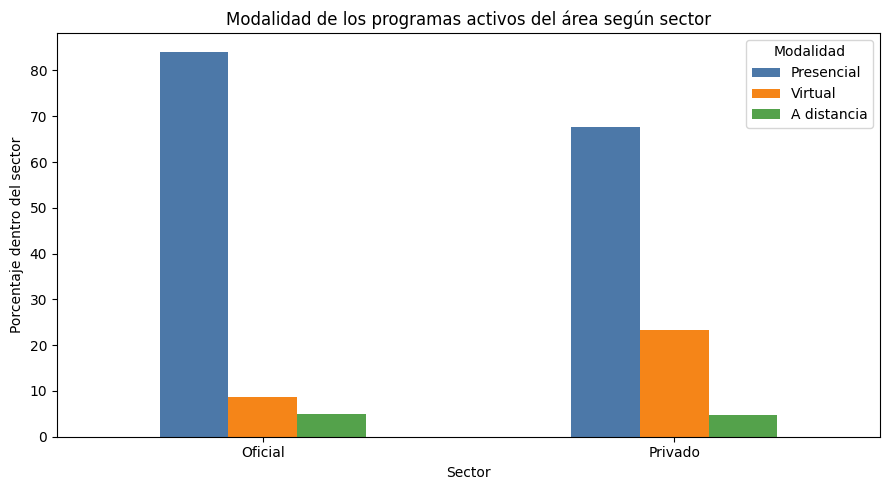

In [77]:
ax = grafico_modalidades.plot(
    kind="bar", figsize=(9, 5),
    color=["#4C78A8", "#F58518", "#54A24B"]
)
ax.set_title("Modalidad de los programas activos del área según sector")
ax.set_xlabel("Sector")
ax.set_ylabel("Porcentaje dentro del sector")
ax.legend(title="Modalidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Pausa práctica: redactar un hallazgo

**Tiempo sugerido: 3–5 minutos.** Consulta el porcentaje virtual por sector y redacta una frase descriptiva, no causal.


In [79]:
print(resumen_sector[["porcentaje_virtual"]].round(1))
sector_mayor = resumen_sector["porcentaje_virtual"].idxmax()
valor_mayor = resumen_sector.loc[sector_mayor, "porcentaje_virtual"]
hallazgo = f"En los registros analizados, el sector {sector_mayor.lower()} presenta el mayor porcentaje de ofertas virtuales ({valor_mayor:.1f}%)."
print(hallazgo)

         porcentaje_virtual
sector                     
Privado                23.3
Oficial                 8.6
En los registros analizados, el sector privado presenta el mayor porcentaje de ofertas virtuales (23.3%).


### Respuesta sugerida


In [ ]:
print(resumen_sector[["porcentaje_virtual"]].round(1))
sector_mayor = resumen_sector["porcentaje_virtual"].idxmax()
valor_mayor = resumen_sector.loc[sector_mayor, "porcentaje_virtual"]
hallazgo = f"En los registros analizados, el sector {sector_mayor.lower()} presenta el mayor porcentaje de ofertas virtuales ({valor_mayor:.1f}%)."
print(hallazgo)


         porcentaje_virtual
sector                     
Privado                21.2
Oficial                 8.0
En los registros analizados, el sector privado presenta el mayor porcentaje de ofertas virtuales (21.2%).


## 16. Raw, bronze, silver y gold

- **raw:** archivos descargados sin modificación;
- **bronze:** copia leída y descrita;
- **silver:** datos limpiados, tipados e integrados;
- **gold:** tabla preparada para una pregunta concreta.

No hace falta una plataforma compleja. Lo esencial es no reemplazar el original y poder reconstruir el resultado.


In [80]:
raw_programas = programas_original
bronze_programas = programas.copy()
silver_programas = programas_integrados.drop(columns="_merge").copy()
gold_resumen_sector = resumen_sector.reset_index().copy()

print("Raw:", raw_programas.shape)
print("Bronze:", bronze_programas.shape)
print("Silver:", silver_programas.shape)
print("Gold:", gold_resumen_sector.shape)


Raw: (32042, 39)
Bronze: (32040, 16)
Silver: (4846, 26)
Gold: (2, 6)


`gold` no significa verdad definitiva. Si cambia la pregunta, puede cambiar la tabla de análisis.


In [81]:
nombre_salida = "resumen_programas_negocios_por_sector.csv"
gold_resumen_sector.to_csv(nombre_salida, index=False, encoding="utf-8-sig")
print("Archivo guardado:", nombre_salida)

Archivo guardado: resumen_programas_negocios_por_sector.csv


## Cierre

Seguimos una secuencia auditable: lectura directa, observación, selección, limpieza, faltantes, filtros, agregaciones, cruce, verificación e interpretación.
